<a href="https://colab.research.google.com/github/nielitropar/computer-vision/blob/main/Face_Recognition_Modue_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Advanced Face Recognition using Python on Google Colab

## Topics Covered

* Real-time webcam recognition
* Multi-face recognition
* Confidence score and threshold tuning
* CSV-based attendance system
* DeepFace introduction
* Emotion, age, and gender analysis
* Clean reusable functions
* Colab-compatible webcam capture

This notebook is designed for beginners transitioning into practical face recognition systems.



## Install Required Libraries


In [1]:
!pip install -q face_recognition deepface opencv-python pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.1 MB/s eta 0:00:00



## Import Libraries


In [2]:
import cv2
import os
import csv
import time
import numpy as np
import pandas as pd
import face_recognition
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from deepface import DeepFace

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

26-05-13 16:31:50 - Directory /root/.deepface has been created
26-05-13 16:31:50 - Directory /root/.deepface/weights has been created



## Webcam Utility Function for Google Colab

Google Colab cannot directly access the webcam using OpenCV.

We use JavaScript + browser webcam APIs to capture images.


In [3]:
def take_photo(filename='photo.jpg', quality=0.9):

    js = '''
    async function takePhoto(quality) {

      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;

      await video.play();

      google.colab.output.setIframeHeight(
          document.documentElement.scrollHeight, true
      );

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();

      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    '''

    display(Javascript(js))

    data = eval_js(f'takePhoto({quality})')

    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename


## Create Dataset Folder


In [4]:
DATASET_DIR = Path("advanced_face_dataset")
DATASET_DIR.mkdir(exist_ok=True)

print("Dataset directory ready.")

Dataset directory ready.



## Add Known Faces to Dataset

Capture multiple images for better accuracy.


**Note:** This cell will ask for permission on 1st run will show error please run again after giving permission

In [6]:
person_name = input("Enter person name: ").strip()

person_dir = DATASET_DIR / person_name
person_dir.mkdir(exist_ok=True)

num_images = int(input("How many images to capture? "))

for i in range(num_images):

    filename = f"{person_name}_{i+1}.jpg"

    photo_path = take_photo(filename)

    destination = person_dir / filename

    os.rename(photo_path, destination)

    print(f"Saved: {destination}")

Enter person name: Sarwan Singh
How many images to capture? 3


<IPython.core.display.Javascript object>

Saved: advanced_face_dataset/Sarwan Singh/Sarwan Singh_1.jpg


<IPython.core.display.Javascript object>

Saved: advanced_face_dataset/Sarwan Singh/Sarwan Singh_2.jpg


<IPython.core.display.Javascript object>

Saved: advanced_face_dataset/Sarwan Singh/Sarwan Singh_3.jpg



## Build Face Encoding Database


In [7]:
known_encodings = []
known_names = []

for person_name in os.listdir(DATASET_DIR):

    person_path = DATASET_DIR / person_name

    for image_name in os.listdir(person_path):

        image_path = person_path / image_name

        image = face_recognition.load_image_file(image_path)

        encodings = face_recognition.face_encodings(image)

        if len(encodings) > 0:

            known_encodings.append(encodings[0])
            known_names.append(person_name)

print("Database Created Successfully")
print("Total Encodings:", len(known_encodings))

Database Created Successfully
Total Encodings: 3



## Real-Time Recognition Simulation

Since Colab does not support continuous OpenCV webcam streaming directly,
we repeatedly capture images from the browser webcam.

This simulates real-time recognition.


<IPython.core.display.Javascript object>

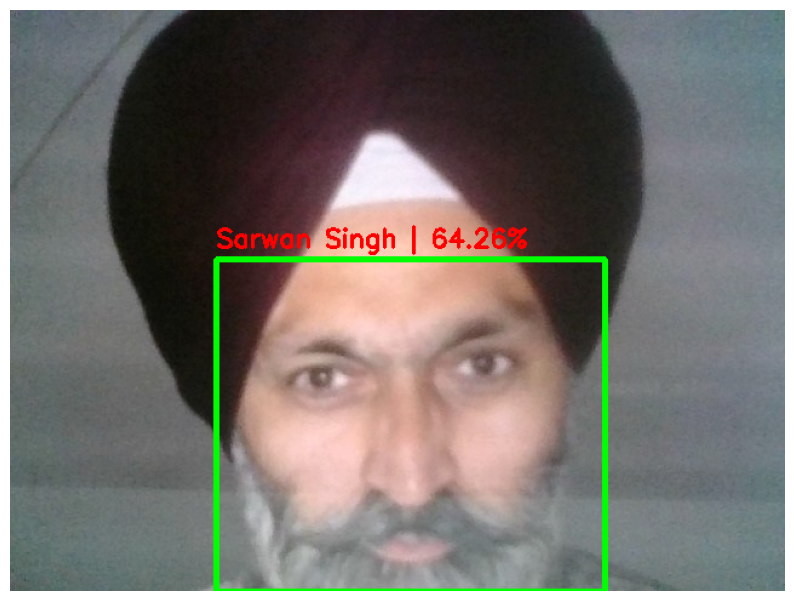

In [8]:
THRESHOLD = 0.50

test_image_path = take_photo("live_test.jpg")

test_image = face_recognition.load_image_file(test_image_path)

face_locations = face_recognition.face_locations(test_image)

face_encodings = face_recognition.face_encodings(
    test_image,
    face_locations
)

image_copy = test_image.copy()

for (top, right, bottom, left), face_encoding in zip(
    face_locations,
    face_encodings
):

    matches = face_recognition.compare_faces(
        known_encodings,
        face_encoding,
        tolerance=THRESHOLD
    )

    face_distances = face_recognition.face_distance(
        known_encodings,
        face_encoding
    )

    name = "Unknown"
    confidence = 0

    if len(face_distances) > 0:

        best_match_index = np.argmin(face_distances)

        confidence = round(
            (1 - face_distances[best_match_index]) * 100,
            2
        )

        if matches[best_match_index]:
            name = known_names[best_match_index]

    cv2.rectangle(
        image_copy,
        (left, top),
        (right, bottom),
        (0, 255, 0),
        3
    )

    label = f"{name} | {confidence}%"

    cv2.putText(
        image_copy,
        label,
        (left, top - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(10, 8))
plt.imshow(image_copy)
plt.axis("off")
plt.show()


## Understanding Confidence Scores

Face recognition works using vector distance.

- Smaller distance = better match
- Larger distance = weaker match

Typical thresholds:

| Threshold | Accuracy |
|---|---|
| 0.4 | Very strict |
| 0.5 | Recommended |
| 0.6 | More flexible |
| 0.7 | Risk of false matches |



## Multi-Face Recognition

This section detects and recognizes multiple faces in a single image.


Choose Input Method:
1 = Take Photo using Webcam
2 = Upload Image

Enter choice (1 or 2): 2


Saving sarwan_sir_1.jpeg to sarwan_sir_1.jpeg
Faces Detected: 1


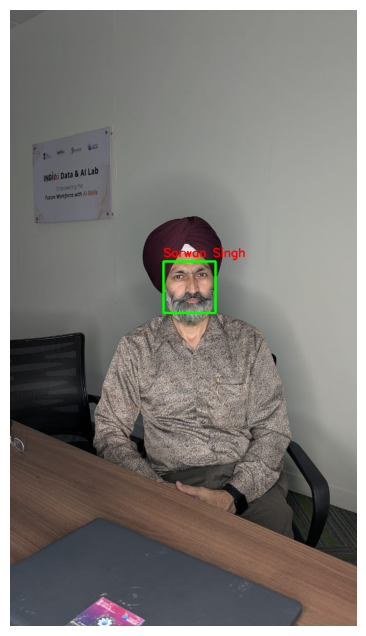

In [9]:
# OPTION: TAKE PHOTO OR UPLOAD IMAGE
from google.colab import files

choice = input(
    "Choose Input Method:\n"
    "1 = Take Photo using Webcam\n"
    "2 = Upload Image\n\n"
    "Enter choice (1 or 2): "
)

# TAKE PHOTO
if choice == "1":

    group_image_path = take_photo("group_photo.jpg")

# UPLOAD IMAGE
elif choice == "2":

    uploaded = files.upload()

    group_image_path = list(uploaded.keys())[0]

else:
    raise ValueError("Invalid choice. Please enter 1 or 2.")

# LOAD IMAGE
group_image = face_recognition.load_image_file(group_image_path)

# DETECT FACES
locations = face_recognition.face_locations(group_image)

encodings = face_recognition.face_encodings(
    group_image,
    locations
)

output_image = group_image.copy()

print("Faces Detected:", len(locations))

# FACE RECOGNITION
for (top, right, bottom, left), encoding in zip(
    locations,
    encodings
):

    matches = face_recognition.compare_faces(
        known_encodings,
        encoding,
        tolerance=0.5
    )

    distances = face_recognition.face_distance(
        known_encodings,
        encoding
    )

    name = "Unknown"

    if len(distances) > 0:

        best_index = np.argmin(distances)

        if matches[best_index]:
            name = known_names[best_index]

    # Draw Rectangle
    cv2.rectangle(
        output_image,
        (left, top),
        (right, bottom),
        (0, 255, 0),
        3
    )

    # Put Name Label
    cv2.putText(
        output_image,
        name,
        (left, top - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 0, 0),
        2
    )

# DISPLAY RESULT
plt.figure(figsize=(12, 8))
plt.imshow(output_image)
plt.axis("off")
plt.show()


# Attendance System using CSV Logging


In [10]:
ATTENDANCE_FILE = "attendance.csv"

if not os.path.exists(ATTENDANCE_FILE):

    with open(ATTENDANCE_FILE, "w", newline="") as f:

        writer = csv.writer(f)

        writer.writerow(["Name", "Time"])

print("Attendance file ready.")

Attendance file ready.


In [11]:
def mark_attendance(name):

    current_time = time.strftime("%Y-%m-%d %H:%M:%S")

    with open(ATTENDANCE_FILE, "a", newline="") as f:

        writer = csv.writer(f)

        writer.writerow([name, current_time])

    print(f"Attendance marked for {name}")

In [12]:
attendance_image_path = take_photo("attendance.jpg")

attendance_image = face_recognition.load_image_file(
    attendance_image_path
)

locations = face_recognition.face_locations(attendance_image)

encodings = face_recognition.face_encodings(
    attendance_image,
    locations
)

for encoding in encodings:

    matches = face_recognition.compare_faces(
        known_encodings,
        encoding,
        tolerance=0.5
    )

    distances = face_recognition.face_distance(
        known_encodings,
        encoding
    )

    if len(distances) > 0:

        best_index = np.argmin(distances)

        if matches[best_index]:

            detected_name = known_names[best_index]

            mark_attendance(detected_name)

<IPython.core.display.Javascript object>

Attendance marked for Sarwan Singh



## View Attendance Records


In [13]:
attendance_df = pd.read_csv("attendance.csv")

attendance_df

,Name,Time
0,Sarwan Singh,2026-05-13 16:36:08



# DeepFace Introduction

DeepFace is a higher-level deep learning library for facial analysis.

Capabilities:

- Face verification
- Face recognition
- Emotion detection
- Age prediction
- Gender prediction
- Race analysis



## Emotion, Age, and Gender Analysis


In [14]:
analysis_image_path = take_photo("analysis.jpg")

result = DeepFace.analyze(
    img_path=analysis_image_path,
    actions=['emotion', 'age', 'gender'],
    enforce_detection=False
)

result

<IPython.core.display.Javascript object>

Action: emotion:   0%|          | 0/3 [00:00<?, ?it/s]

26-05-13 16:36:37 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5

100%|██████████| 5.98M/5.98M [00:00<00:00, 307MB/s]
Action: age:  33%|███▎      | 1/3 [00:01<00:03,  1.55s/it]    

26-05-13 16:36:39 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /root/.deepface/weights/age_model_weights.h5

  0%|          | 0.00/539M [00:00<?, ?B/s]
  2%|▏         | 11.0M/539M [00:00<00:11, 45.2MB/s]
  4%|▍         | 21.5M/539M [00:00<00:12, 43.0MB/s]
  6%|▌         | 32.0M/539M [00:00<00:11, 43.8MB/s]
  8%|▊         | 42.5M/539M [00:00<00:11, 43.6MB/s]
 10%|▉         | 53.0M/539M [00:01<00:11, 44.0MB/s]
 12%|█▏        | 63.4M/539M [00:01<00:10, 43.3MB/s]
 14%|█▎        | 73.9M/539M [00:01<00:10, 42.8MB/s]
 16%|█▌        | 84.4M/539M [00:01<00:10, 41.6MB/s]
 18%|█▊        | 94.9M/539M [00:02<00:10, 41.4MB/s]
 20%|█▉        | 105M/539M [00:02<00:10, 41.4MB/s] 
 22%|██▏       | 116M/539M [00:02<00:10, 41.4MB/s]
 23%|██▎       | 126M/539M [00:02<00:09, 42.5MB/s]
 25%|██▌       | 137M/539M [00:03<00:09, 42.3MB/s]
 27%|██▋       | 147M/539M [00:03<00:09, 42.6MB/s]
 29%|██▉       | 158M/539M [00:03<00:09, 42.1MB/s]
 36%|███▌      | 194M/5

26-05-13 16:36:48 - 🔗 gender_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5 to /root/.deepface/weights/gender_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5
To: /root/.deepface/weights/gender_model_weights.h5

  0%|          | 0.00/537M [00:00<?, ?B/s]
  9%|▉         | 47.2M/537M [00:00<00:01, 471MB/s]
 18%|█▊        | 94.4M/537M [00:00<00:01, 434MB/s]
 26%|██▌       | 138M/537M [00:00<00:00, 412MB/s] 
 33%|███▎      | 180M/537M [00:00<00:00, 401MB/s]
 41%|████      | 220M/537M [00:00<00:00, 392MB/s]
 49%|████▊     | 261M/537M [00:00<00:00, 395MB/s]
 57%|█████▋    | 304M/537M [00:00<00:00, 406MB/s]
 64%|██████▍   | 344M/537M [00:00<00:00, 389MB/s]
 71%|███████▏  | 384M/537M [00:00<00:00, 386MB/s]
 79%|███████▉  | 424M/537M [00:01<00:00, 391MB/s]
 86%|████████▋ | 463M/537M [00:01<00:00, 354MB/s]
 93%|█████████▎| 500M/537M [00:01<00:00, 333MB/s]
100%|██████████| 537M/537M [00:01<00:00, 366MB/s]
Action: gender: 100%|██████████| 3/3 [00:13<00:00,  4.67s/it]


[{'emotion': {'angry': np.float32(11.353112),
   'disgust': np.float32(0.0010359903),
   'fear': np.float32(11.004195),
   'happy': np.float32(0.8157832),
   'sad': np.float32(11.414254),
   'surprise': np.float32(0.6715373),
   'neutral': np.float32(64.74009)},
  'dominant_emotion': 'neutral',
  'region': {'x': 129,
   'y': 167,
   'w': 324,
   'h': 312,
   'left_eye': (345, 287),
   'right_eye': (220, 303)},
  'face_confidence': 0.93,
  'age': 26,
  'gender': {'Woman': np.float32(0.011818959), 'Man': np.float32(99.988174)},
  'dominant_gender': 'Man'}]


## Display Analysis Results Nicely


In [16]:
if isinstance(result, list):
    result = result[0]

print("Predicted Age:", result['age'])
print("Predicted Gender:", result['dominant_gender'])
print("Dominant Emotion:", result['dominant_emotion'])

Predicted Age: 26
Predicted Gender: Man
Dominant Emotion: neutral



# Best Practices

- Use multiple training images
- Maintain proper lighting
- Avoid blurry images
- Tune thresholds carefully
- Store embeddings securely
- Respect privacy and consent



# Exercises

1. Build live classroom attendance
2. Save recognized face snapshots
3. Add anti-spoofing
4. Build Flask-based face recognition app
5. Create face login system



# Congratulations

You successfully built:

- Multi-face recognition
- Real-time recognition workflow
- Confidence-based prediction
- CSV attendance system
- DeepFace analysis system

*You are now ready to build production-grade AI face recognition projects.*
